In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_style('whitegrid')

# Load the dataset
df = pd.read_csv('IMDB Dataset.csv')

# Basic info
print("Shape of dataset:", df.shape)
print("\nColumn names and data types:")
print(df.dtypes)
print("\nFirst 5 rows:")
df.head()

Shape of dataset: (50000, 2)

Column names and data types:
review       object
sentiment    object
dtype: object

First 5 rows:


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [2]:
# ===== DATA QUALITY REPORT =====

print("="*50)
print("DATA QUALITY REPORT")
print("="*50)

# 1. Null values per column
print("\n--- Null Values Per Column ---")
print(df.isnull().sum())

print("\n--- Percentage of Nulls ---")
print((df.isnull().sum() / len(df) * 100).round(2))

# 2. Duplicate rows
print("\n--- Duplicate Rows ---")
print("Number of duplicate rows:", df.duplicated().sum())

# 3. Data type issues
print("\n--- Data Types ---")
print(df.dtypes)

# 4. Unique values in the label column (helps spot inconsistent labels)
print("\n--- Unique Values in 'sentiment' ---")
print(df['sentiment'].unique())
print(df['sentiment'].value_counts())

DATA QUALITY REPORT

--- Null Values Per Column ---
review       0
sentiment    0
dtype: int64

--- Percentage of Nulls ---
review       0.0
sentiment    0.0
dtype: float64

--- Duplicate Rows ---


Number of duplicate rows: 418

--- Data Types ---
review       object
sentiment    object
dtype: object

--- Unique Values in 'sentiment' ---
['positive' 'negative']
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [3]:
# ===== DUPLICATE REMOVAL =====

# Reason: The same review repeated can make the model look better than it really is
print("Number of duplicate rows before removal:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates().reset_index(drop=True)

print("Number of duplicate rows after removal:", df.duplicated().sum())
print("New shape of dataset:", df.shape)

Number of duplicate rows before removal: 418


Number of duplicate rows after removal: 0
New shape of dataset: (49582, 2)


In [4]:
# ===== TEXT CLEANING =====

# Steps and reasons:
# 1. Remove HTML tags   -> many reviews contain <br />, which is not part of the opinion
# 2. Convert lowercase  -> so 'Great' and 'great' are treated as the same word
# 3. Keep only letters  -> punctuation, numbers and symbols do not help this model
# 4. Remove extra space -> tidy up after the earlier steps

def clean_text(text):
    text = re.sub(r'<.*?>', ' ', text)
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Keep the original 'review' column and add a new 'clean_review' column
df['clean_review'] = df['review'].apply(clean_text)

print("--- BEFORE cleaning (first review) ---")
print(df['review'][0][:400])
print("\n--- AFTER cleaning (first review) ---")
print(df['clean_review'][0][:400])

--- BEFORE cleaning (first review) ---
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to

--- AFTER cleaning (first review) ---
one of the other reviewers has mentioned that after watching just oz episode you ll be hooked they are right as this is exactly what happened with me the first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not a show for the faint hearted or timid this show pulls no punches with regards to drugs sex or violen


--- Review counts ---
sentiment
positive    24884
negative    24698
Name: count, dtype: int64

--- Percentage ---
sentiment
positive    50.19
negative    49.81
Name: count, dtype: float64


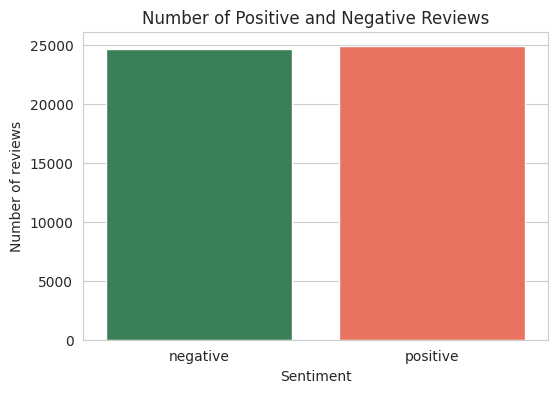

In [5]:
# ===== SENTIMENT DISTRIBUTION =====

counts = df['sentiment'].value_counts()
print("--- Review counts ---")
print(counts)
print("\n--- Percentage ---")
print((counts / len(df) * 100).round(2))

plt.figure(figsize=(6, 4))
sns.countplot(x='sentiment', hue='sentiment', data=df, palette=['tomato', 'seagreen'],
              order=['negative', 'positive'], legend=False)
plt.title('Number of Positive and Negative Reviews')
plt.xlabel('Sentiment')
plt.ylabel('Number of reviews')
plt.savefig('chart1_sentiment_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

# Observation: After removing duplicates there are 49,582 reviews - 24,884 positive
# (50.19%) and 24,698 negative (49.81%). The classes are almost perfectly balanced,
# so accuracy is a fair measure here and no balancing technique is needed.

In [6]:
# ===== REVIEW LENGTH ANALYSIS =====

# Count the number of words in each cleaned review
df['word_count'] = df['clean_review'].apply(lambda x: len(x.split()))

print("--- Word count statistics (all reviews) ---")
print(df['word_count'].describe().round(1))

print("\n--- Word count by sentiment ---")
print(df.groupby('sentiment')['word_count'].agg(['mean', 'median', 'min', 'max']).round(1))

--- Word count statistics (all reviews) ---
count    49582.0
mean       234.4
std        173.7
min          6.0
25%        128.0
50%        176.0
75%        284.0
max       2494.0
Name: word_count, dtype: float64

--- Word count by sentiment ---
            mean  median  min   max
sentiment                          
negative   232.8   177.0    6  1539
positive   236.0   175.0   10  2494


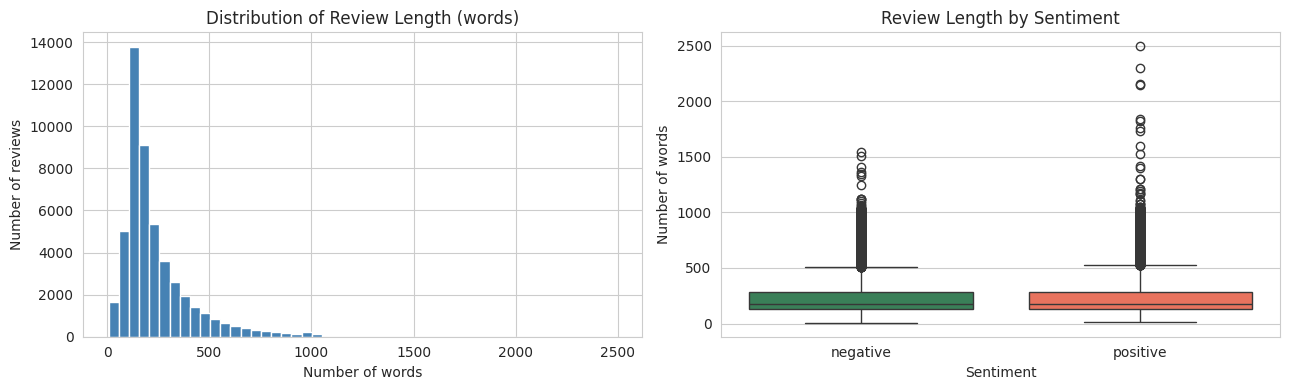

In [7]:
# ===== REVIEW LENGTH CHARTS =====

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['word_count'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Review Length (words)')
axes[0].set_xlabel('Number of words')
axes[0].set_ylabel('Number of reviews')

sns.boxplot(x='sentiment', y='word_count', hue='sentiment', data=df, palette=['tomato', 'seagreen'],
            order=['negative', 'positive'], legend=False, ax=axes[1])
axes[1].set_title('Review Length by Sentiment')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Number of words')

plt.tight_layout()
plt.savefig('chart2_review_length.png', dpi=120, bbox_inches='tight')
plt.show()

# Observation (histogram): Most reviews are fairly short. The average is about 234 words
# but the median is 176, and the longest review has 2,494 words. The chart is skewed to
# the right - a small number of very long reviews pull the average up.
#
# Observation (boxplot): Positive and negative reviews have very similar lengths
# (mean 236.0 vs 232.8 words, median 175 vs 177). Length of a review does not tell us
# whether it is positive or negative. Dots above the boxes are unusually long reviews.

In [8]:
# ===== TRAIN-TEST SPLIT =====

# Convert labels to numbers: negative = 0, positive = 1
X = df['clean_review']
y = df['sentiment'].map({'negative': 0, 'positive': 1})

# 80% training, 20% testing
# Reason: stratify keeps the same positive/negative ratio in both parts,
#         random_state makes the result the same every time
# Note: split is done BEFORE TF-IDF so the test reviews do not influence what the vectoriser learns
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Training reviews:", X_train.shape[0])
print("Testing reviews :", X_test.shape[0])
print("\nTraining label split (%):")
print((y_train.value_counts(normalize=True) * 100).round(2))

Training reviews: 39665
Testing reviews : 9917

Training label split (%):
sentiment
1    50.19
0    49.81
Name: proportion, dtype: float64


In [9]:
# ===== TF-IDF FEATURE EXTRACTION =====

# Reason: A model cannot read words, only numbers. TF-IDF gives each word a score -
# words used often in a review score higher, words used in almost every review
# (like 'the') are scaled down.
# stop_words='english' removes very common words, max_features=5000 keeps the 5000 most useful words
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)   # learn words from training data only
X_test_tfidf = tfidf.transform(X_test)

print("Training matrix shape:", X_train_tfidf.shape)
print("Testing matrix shape :", X_test_tfidf.shape)

Training matrix shape: (39665, 5000)
Testing matrix shape : (9917, 5000)


In [10]:
# ===== MODEL TRAINING =====

# Reason: Logistic Regression is simple, fast, works well with TF-IDF text data,
# and its results are easy to explain
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

print("Model training finished")

Model training finished


In [11]:
# ===== MODEL EVALUATION =====

y_pred = model.predict(X_test_tfidf)

# 1. Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 4))
print("Accuracy in percent:", round(acc * 100, 2), "%")

# 2. Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\n--- Confusion Matrix ---")
print(cm)

# 3. Classification report
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

Accuracy: 0.8838
Accuracy in percent: 88.38 %

--- Confusion Matrix ---
[[4293  647]
 [ 505 4472]]

--- Classification Report ---
              precision    recall  f1-score   support

    Negative       0.89      0.87      0.88      4940
    Positive       0.87      0.90      0.89      4977

    accuracy                           0.88      9917
   macro avg       0.88      0.88      0.88      9917
weighted avg       0.88      0.88      0.88      9917



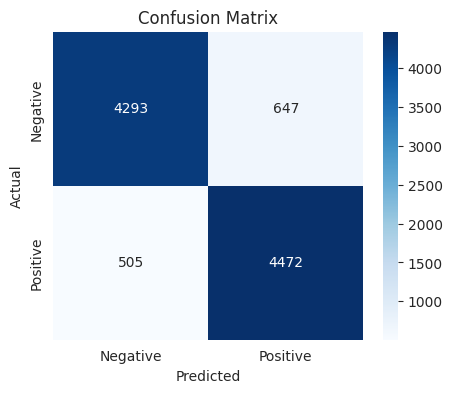

In [12]:
# ===== CONFUSION MATRIX CHART =====

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('chart3_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

# Observation: Out of 9,917 test reviews the model correctly identified 4,293 negative
# and 4,472 positive reviews. It called 647 negative reviews positive and 505 positive
# reviews negative. The two kinds of error are similar in size, so the model is not
# strongly biased towards one class.
#
# Observation (report): Accuracy is about 88%. Precision, recall and F1-score are between
# 0.87 and 0.90 for both classes. Recall for positive reviews (0.90) is slightly higher
# than for negative reviews (0.87), matching the confusion matrix.

In [13]:
# ===== SAMPLE TEST PREDICTIONS =====

results = pd.DataFrame({
    'review_start': X_test.str[:120],
    'actual': y_test.map({0: 'negative', 1: 'positive'}),
    'predicted': pd.Series(y_pred, index=y_test.index).map({0: 'negative', 1: 'positive'})
})
results['correct'] = results['actual'] == results['predicted']

# Show 10 random reviews from the test set
pd.set_option('display.max_colwidth', 130)
results.sample(10, random_state=1)

# Observation: In this random sample 9 of 10 were predicted correctly. The one mistake was
# a negative review predicted as positive. Reviews with obvious words ('stupid',
# 'enjoyable') are easy; reviews that discuss plot facts or use sarcasm are harder.

,review_start,actual,predicted,correct
2009,stuck in a hotel in kuwait i happily switched to the channel showing this at the very beginning first pachelbel s canon,positive,positive,True
27280,one of the major aspects of malenkaya vera called little vera in english is that it was the first movie from the soviet,positive,positive,True
32406,as others have mentioned all the women that go nude in this film are mostly absolutely gorgeous the plot very ably shows,positive,positive,True
30408,imagine the most cliche ridden b movie horror plot you can add more plot holes than plot have it scripted by a year old,negative,negative,True
9638,critters ranks as one of the greatest films of the twentieth century the word classic has never been so aptly used as in,positive,positive,True
47865,lois weber self proclaimed missionary via the cinema wrote directed and produced other films on controversial subjects b,negative,positive,False
39495,i was pleasantly surprised to find a very enjoyable film that kept my attention throughout i am a horror fan and i see a,positive,positive,True
18847,this film is definitely a product of its times and seen in any other context it is an incredibly stupid movie heck even,negative,negative,True
8382,okay now i know there are millions of americans who believe in the rapture that moment when all people born again in chr,negative,negative,True
12736,final score an average of various classic cinematic qualities acting visuals creativity payoff humor fun ect out of had,negative,negative,True


Top negative words: ['worst', 'awful', 'waste', 'bad', 'boring', 'poor', 'terrible', 'horrible', 'dull', 'poorly', 'worse', 'disappointment', 'fails', 'annoying', 'lame']
Top positive words: ['great', 'excellent', 'perfect', 'amazing', 'best', 'wonderful', 'favorite', 'brilliant', 'loved', 'today', 'hilarious', 'enjoyed', 'superb', 'enjoyable', 'fun']


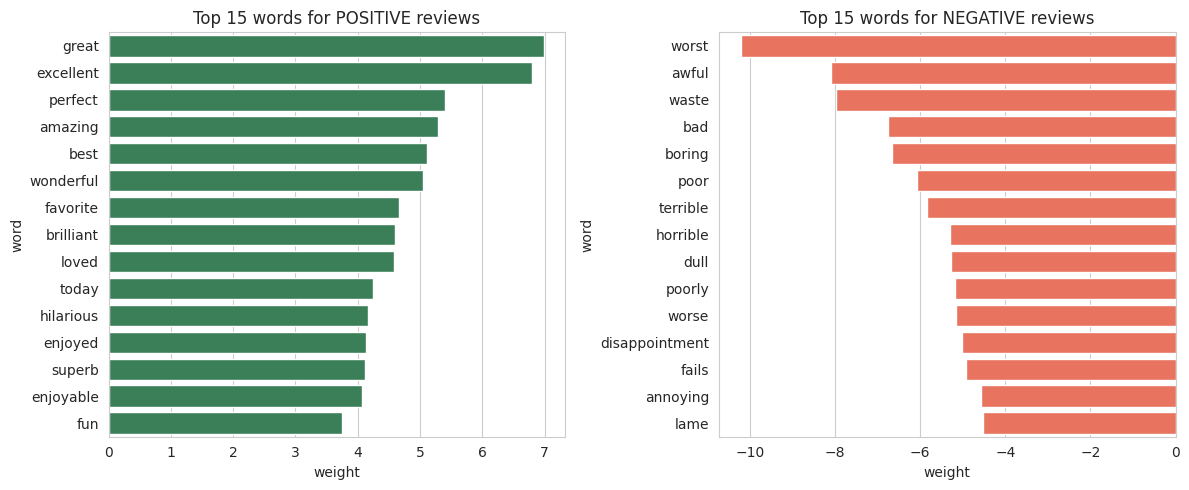

In [14]:
# ===== TOP WORDS FOR EACH SENTIMENT =====

# In Logistic Regression each word gets a weight:
# large positive weight -> positive review, large negative weight -> negative review
words = np.array(tfidf.get_feature_names_out())
weights = model.coef_[0]

order = np.argsort(weights)
top_neg = pd.DataFrame({'word': words[order[:15]], 'weight': weights[order[:15]]})
top_pos = pd.DataFrame({'word': words[order[-15:]][::-1], 'weight': weights[order[-15:]][::-1]})

print("Top negative words:", top_neg['word'].tolist())
print("Top positive words:", top_pos['word'].tolist())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(x='weight', y='word', data=top_pos, color='seagreen', ax=axes[0])
axes[0].set_title('Top 15 words for POSITIVE reviews')
sns.barplot(x='weight', y='word', data=top_neg, color='tomato', ax=axes[1])
axes[1].set_title('Top 15 words for NEGATIVE reviews')
plt.tight_layout()
plt.savefig('chart4_top_words.png', dpi=120, bbox_inches='tight')
plt.show()

# Observation: Negative reviews are pushed by words like 'worst', 'awful', 'waste',
# 'boring' and 'terrible'. Positive reviews are pushed by 'great', 'excellent',
# 'perfect', 'amazing' and 'wonderful'. The model has learned real opinion words,
# not random patterns.

length_group
0-100      89.27
101-200    88.11
201-400    87.91
400+       89.47
Name: correct, dtype: float64


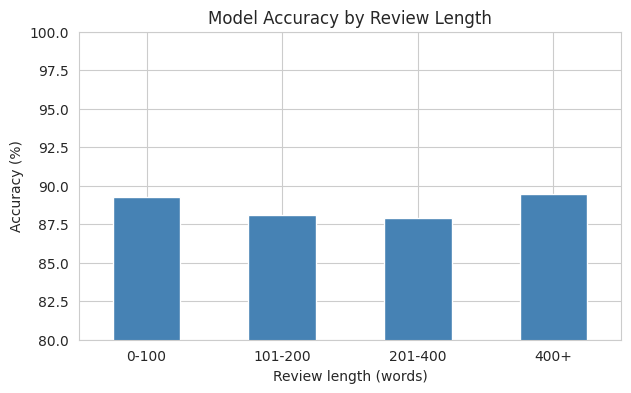

In [15]:
# ===== ACCURACY BY REVIEW LENGTH =====

# Check whether the model is better or worse on short/long reviews
results['word_count'] = df.loc[X_test.index, 'word_count']
results['length_group'] = pd.cut(results['word_count'],
                                 bins=[0, 100, 200, 400, 5000],
                                 labels=['0-100', '101-200', '201-400', '400+'])

acc_by_length = results.groupby('length_group', observed=True)['correct'].mean() * 100
print(acc_by_length.round(2))

plt.figure(figsize=(7, 4))
acc_by_length.plot(kind='bar', color='steelblue')
plt.title('Model Accuracy by Review Length')
plt.xlabel('Review length (words)')
plt.ylabel('Accuracy (%)')
plt.ylim(80, 100)
plt.xticks(rotation=0)
plt.savefig('chart5_accuracy_by_length.png', dpi=120, bbox_inches='tight')
plt.show()

# Observation: Accuracy stays between about 88% and 89% for every length group, so
# review length does not affect the model much.

In [16]:
# ===== BEFORE VS AFTER SUMMARY =====

# Re-load original dataset for comparison (fresh copy)
df_original = pd.read_csv('IMDB Dataset.csv')

summary = pd.DataFrame({
    'Metric': [
        'Total Rows',
        'Total Columns',
        'Null Values (Total)',
        'Duplicate Rows',
        'Positive Reviews',
        'Negative Reviews'
    ],
    'Before Cleaning': [
        df_original.shape[0],
        df_original.shape[1],
        df_original.isnull().sum().sum(),
        df_original.duplicated().sum(),
        (df_original['sentiment'] == 'positive').sum(),
        (df_original['sentiment'] == 'negative').sum()
    ],
    'After Cleaning': [
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        (df['sentiment'] == 'positive').sum(),
        (df['sentiment'] == 'negative').sum()
    ]
})

print(summary.to_string(index=False))

             Metric  Before Cleaning  After Cleaning
         Total Rows            50000           49582
      Total Columns                2               4
Null Values (Total)                0               0
     Duplicate Rows              418               0
   Positive Reviews            25000           24884
   Negative Reviews            25000           24698


In [17]:
# ===== SAVE OUTPUT FILES =====

# Save test predictions and a 1000-row sample of the cleaned data
results.to_csv('Test_Predictions.csv', index=False)
df[['review', 'clean_review', 'sentiment', 'word_count']].head(1000).to_csv('IMDB_Cleaned_Sample.csv', index=False)
print("Saved 'Test_Predictions.csv' and 'IMDB_Cleaned_Sample.csv'")

# Verify
df_check = pd.read_csv('Test_Predictions.csv')
print("\nShape of saved predictions file:", df_check.shape)
df_check.head()

Saved 'Test_Predictions.csv' and 'IMDB_Cleaned_Sample.csv'

Shape of saved predictions file: (9917, 6)


,review_start,actual,predicted,correct,word_count,length_group
0,my wife and i watched this after dvr ing it off of encore action this past week it has to be the worst horror flick eith,negative,negative,True,188,101-200
1,i was surprised how much i enjoyed this sure it is a bit slow moving in parts but what else would one expect from rollin,positive,positive,True,191,101-200
2,such a delightful movie very heart warming one can t help falling in love with the character of gigi he s adorable as a,positive,positive,True,149,101-200
3,la lupa mannara aka werewolf woman of is a film with a highly promising title but sadly the film itself is pretty far aw,negative,negative,True,482,400+
4,first this movie was not that bad it was entertaining at least to me for probably all the wrong reasons i have never see,negative,negative,True,378,201-400


In [18]:
# ===== FINAL CONCLUSION =====

# What was analysed:
# The IMDb 50K movie review dataset (review text + positive/negative label). The data was
# inspected, cleaned (418 duplicates removed, HTML tags/punctuation removed, lowercase),
# explored, and used to build a sentiment classifier.
#
# Important findings:
# - The dataset is balanced: about 50% positive and 50% negative reviews.
# - Review length is almost the same for both sentiments (average about 234 words),
#   so length is not a useful clue for sentiment.
# - The strongest words are easy to understand: 'worst', 'awful', 'waste' (negative)
#   and 'great', 'excellent', 'amazing' (positive).
#
# Model performance:
# TF-IDF (5,000 words) + Logistic Regression reached about 88.4% accuracy on 9,917 unseen
# test reviews. Precision, recall and F1 were about 0.87 to 0.90 for both classes, errors
# were spread evenly, and accuracy was similar for short and long reviews.
#
# Limitations:
# - TF-IDF looks at single words, so it misses word order, sarcasm and negation ('not good').
# - Only 5,000 words, one model and one train/test split were used.
# - Movie reviews are one type of text; the model may do worse on other topics.
# - Only positive/negative labels exist, so neutral or mixed reviews are not covered.
#
# Possible future improvements:
# - Add bigrams (two-word phrases) to TF-IDF.
# - Compare other models (Naive Bayes, Linear SVM) and use cross-validation.
# - Tune model settings.
# - Try word embeddings or a pre-trained transformer model.

print("Final model accuracy: {:.2f}%".format(acc * 100))

Final model accuracy: 88.38%
